In [2]:
import pandas as pd

df = pd.read_csv("reduced_dataset.csv")
df.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target
0,17742,200000,2,3,2,63,-1,3,2,-1,...,316,316,316,0,0,316,316,316,316,1
1,4625,240000,2,2,1,37,0,-1,-1,0,...,1932,7363,1546,1346,3195,0,7383,1546,4390,0
2,1737,80000,2,2,2,29,2,0,0,0,...,67972,66800,68693,2661,2509,2500,3000,3000,3000,1
3,28197,360000,2,2,1,40,-1,-1,-1,-1,...,41301,10889,2017,27930,692,41303,10893,2017,13894,0
4,19220,300000,2,3,1,34,-2,-2,-2,-2,...,-20,-20,4045,29089,21286,0,0,4065,0,0


In [3]:
#Check dataset
print(df.shape)
print(df.columns)

(4000, 25)
Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'target'],
      dtype='object')


In [15]:
#fuzzy
import numpy as np

def low(x, a, b):
    if x <= a: return 1
    elif x >= b: return 0
    else: return (b - x) / (b - a)

def high(x, a, b):
    if x <= a: return 0
    elif x >= b: return 1
    else: return (x - a) / (b - a)
#Step 2: Fuzzify Inputs
def fuzzify(row):
    
    pay0_high = high(row['PAY_0'], 1, 4)
    limit_low = low(row['LIMIT_BAL'], 30000, 100000)
    bill_high = high(row['BILL_AMT1'], 20000, 80000)
    pay_amt_low = low(row['PAY_AMT1'], 500, 3000)
    
    return pay0_high, limit_low, bill_high, pay_amt_low
#Step 3: Define Fuzzy Rules
def fuzzy_rules(fuzzy_values):
    
    pay0_high, limit_low, bill_high, pay_amt_low = fuzzy_values
    
    # Rule strengths
    rule1 = min(pay0_high, limit_low)      # Late payment + low limit
    rule2 = min(bill_high, pay_amt_low)    # High bill + low payment
    rule3 = pay0_high                      # Only late payment
    
    return rule1, rule2, rule3
# Step 4: Defuzzification (Final Risk Score)
def defuzzify(rules):
    
    # Assign weights to rules
    weights = [0.7, 0.8, 0.5]
    
    numerator = sum(r * w for r, w in zip(rules, weights))
    denominator = sum(rules) if sum(rules) != 0 else 1
    
    return numerator / denominator
# Step 5: Apply to Dataset
fuzzy_scores = []

for _, row in df.iterrows():
    
    fuzzy_vals = fuzzify(row)
    rules = fuzzy_rules(fuzzy_vals)
    score = defuzzify(rules)
    
    fuzzy_scores.append(score)

df['Fuzzy_Risk'] = fuzzy_scores
# Step 6: Classify Risk Levels
def fuzzy_label(score):
    if score > 0.7:
        return "High Risk"
    elif score > 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"

df['Fuzzy_Label'] = df['Fuzzy_Risk'].apply(fuzzy_label)
df

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target,Risk_Score,Reason,Risk_Level,Fuzzy_Risk,Fuzzy_Label
0,17742,200000,2,3,2,63,-1,3,2,-1,...,316,316,316,316,1,1,Low Payment,Low Risk,0.000000,Low Risk
1,4625,240000,2,2,1,37,0,-1,-1,0,...,0,7383,1546,4390,0,0,Normal Behavior,Low Risk,0.000000,Low Risk
2,1737,80000,2,2,2,29,2,0,0,0,...,2500,3000,3000,3000,1,1,High Bill Amount,Low Risk,0.629627,Medium Risk
3,28197,360000,2,2,1,40,-1,-1,-1,-1,...,41303,10893,2017,13894,0,0,Normal Behavior,Low Risk,0.000000,Low Risk
4,19220,300000,2,3,1,34,-2,-2,-2,-2,...,0,0,4065,0,0,0,Normal Behavior,Low Risk,0.000000,Low Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,24670,480000,1,1,1,37,1,-1,-1,-1,...,25753,14012,10021,12462,0,0,Normal Behavior,Low Risk,0.000000,Low Risk
3996,18709,130000,2,1,2,27,0,0,0,-2,...,0,0,0,0,0,0,Normal Behavior,Low Risk,0.800000,High Risk
3997,13280,10000,1,2,2,43,2,-1,-1,-1,...,5954,0,1308,0,1,2,"Low Credit Limit, Low Payment",Medium Risk,0.600000,Medium Risk
3998,28931,60000,2,2,1,45,0,0,0,0,...,1525,3124,29484,1326,0,1,High Bill Amount,Low Risk,0.000000,Low Risk


In [18]:
import pandas as pd
import numpy as np

# ==============================
# STEP 1: LOAD DATASET
# ==============================
df = pd.read_csv("reduced_dataset.csv")

print("Dataset Loaded!")
print("Shape:", df.shape)


# ==============================
# STEP 2: CREATE BASE RISK (for table columns)
# ==============================
risk_scores = []
reasons = []
levels = []

for _, row in df.iterrows():
    
    risk = 0
    reason = []

    if row['PAY_0'] > 1:
        risk += 1
        reason.append("Late Payment")

    if row['LIMIT_BAL'] < 100000:
        risk += 1
        reason.append("Low Credit Limit")

    if row['BILL_AMT1'] > 30000:
        risk += 1
        reason.append("High Bill Amount")

    if row['PAY_AMT1'] < 2000:
        risk += 1
        reason.append("Low Payment")

    risk_scores.append(risk)

    if risk >= 3:
        levels.append("High Risk")
    elif risk == 2:
        levels.append("Medium Risk")
    else:
        levels.append("Low Risk")

    if len(reason) == 0:
        reasons.append("Normal Behavior")
    else:
        reasons.append(", ".join(reason))

df['Risk_Score'] = risk_scores
df['Reason'] = reasons
df['Risk_Level'] = levels


# ==============================
# STEP 3: FUZZY FUNCTIONS
# ==============================
def low(x, a, b):
    if x <= a: return 1
    elif x >= b: return 0
    else: return (b - x) / (b - a)

def high(x, a, b):
    if x <= a: return 0
    elif x >= b: return 1
    else: return (x - a) / (b - a)


# ==============================
# STEP 4: FUZZIFICATION
# ==============================
def fuzzify(row):
    return (
        high(row['PAY_0'], 1, 4),
        low(row['LIMIT_BAL'], 30000, 100000),
        high(row['BILL_AMT1'], 20000, 80000),
        low(row['PAY_AMT1'], 500, 3000)
    )


# ==============================
# STEP 5: FUZZY RULES
# ==============================
def fuzzy_rules(vals):
    pay0_high, limit_low, bill_high, pay_low = vals
    
    rule1 = min(pay0_high, limit_low)
    rule2 = min(bill_high, pay_low)
    rule3 = pay0_high
    
    return rule1, rule2, rule3


# ==============================
# STEP 6: DEFUZZIFICATION
# ==============================
def defuzzify(rules):
    weights = [0.7, 0.8, 0.5]
    num = sum(r * w for r, w in zip(rules, weights))
    den = sum(rules) if sum(rules) != 0 else 1
    return num / den


# ==============================
# STEP 7: APPLY FUZZY
# ==============================
scores = []

for _, row in df.iterrows():
    f = fuzzify(row)
    r = fuzzy_rules(f)
    s = defuzzify(r)
    scores.append(s)

df['Fuzzy_Risk'] = scores


# ==============================
# STEP 8: CLASSIFY FUZZY
# ==============================
def label(score):
    if score > 0.7:
        return "High Risk"
    elif score > 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"

df['AI_Result'] = df['Fuzzy_Risk'].apply(label)


# ==============================
# STEP 9: FINAL TABLE
# ==============================
print("\n===== FINAL TABLE =====")

print(df[['ID','LIMIT_BAL','SEX','EDUCATION','MARRIAGE','AGE',
          'PAY_0','PAY_2','PAY_3','PAY_4',
          'BILL_AMT1','PAY_AMT1',
          'target',
          'Risk_Score','Reason','Risk_Level',
          'Fuzzy_Risk','AI_Result'
         ]])


# ==============================
# STEP 10: RISK DISTRIBUTION
# ==============================
print("\n===== RISK DISTRIBUTION =====")
print(df['AI_Result'].value_counts())


# ==============================
# STEP 11: FINAL COMPARISON
# ==============================
comparison = pd.crosstab(df['AI_Result'], df['target'])
comparison['Total'] = comparison.sum(axis=1)
comparison.loc['Total'] = comparison.sum()

print("\n===== FINAL COMPARISON =====")
print(comparison)


# ==============================
# STEP 12: SAVE FILE
# ==============================
df.to_csv("final_fuzzy_output.csv", index=False)
print("\nSaved as final_fuzzy_output.csv")

Dataset Loaded!
Shape: (4000, 25)

===== FINAL TABLE =====
         ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  \
0     17742     200000    2          3         2   63     -1      3      2   
1      4625     240000    2          2         1   37      0     -1     -1   
2      1737      80000    2          2         2   29      2      0      0   
3     28197     360000    2          2         1   40     -1     -1     -1   
4     19220     300000    2          3         1   34     -2     -2     -2   
...     ...        ...  ...        ...       ...  ...    ...    ...    ...   
3995  24670     480000    1          1         1   37      1     -1     -1   
3996  18709     130000    2          1         2   27      0      0      0   
3997  13280      10000    1          2         2   43      2     -1     -1   
3998  28931      60000    2          2         1   45      0      0      0   
3999  13764     280000    2          1         2   27      0      0      0   

    

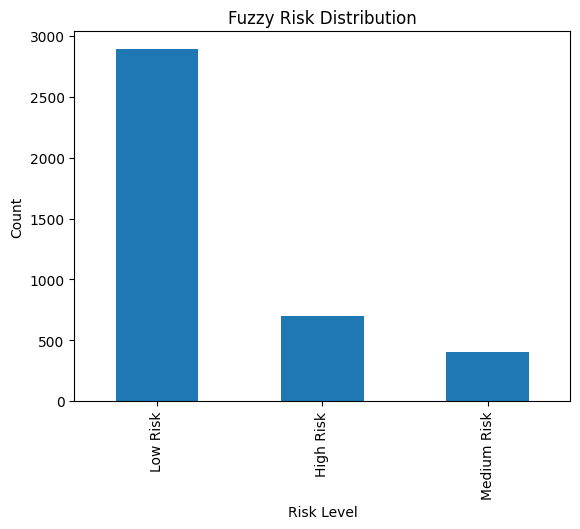

In [19]:
#RISK DISTRIBUTION (BAR GRAPH)
import matplotlib.pyplot as plt

df['AI_Result'].value_counts().plot(kind='bar')

plt.title("Fuzzy Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

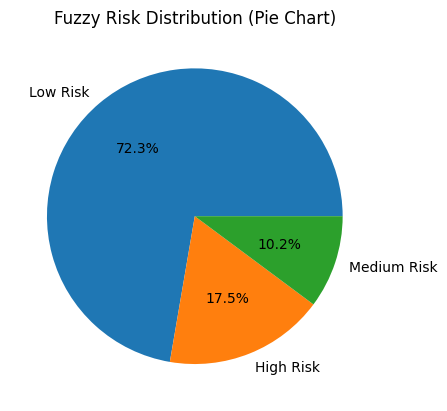

In [20]:
df['AI_Result'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Fuzzy Risk Distribution (Pie Chart)")
plt.ylabel("")
plt.show()

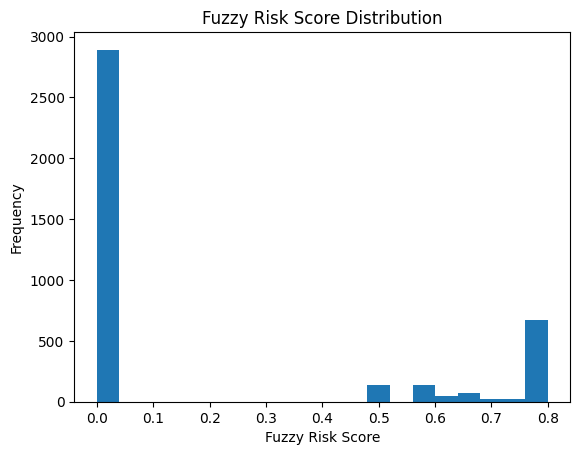

In [21]:
#Fuzzy Score Distribution
plt.hist(df['Fuzzy_Risk'], bins=20)

plt.title("Fuzzy Risk Score Distribution")
plt.xlabel("Fuzzy Risk Score")
plt.ylabel("Frequency")
plt.show()

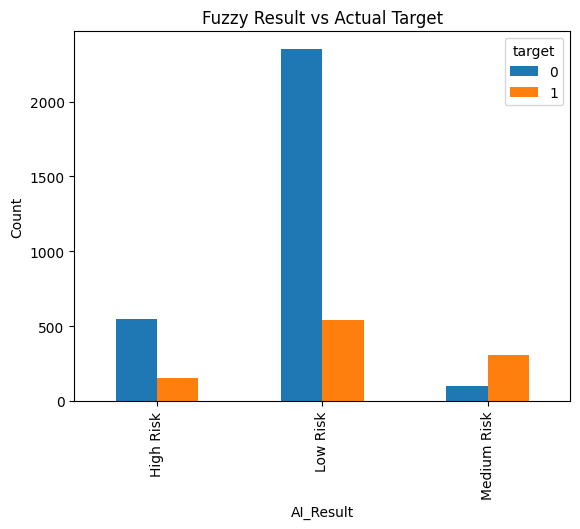

In [22]:
#COMPARISON WITH ACTUAL TARGET
comparison = pd.crosstab(df['AI_Result'], df['target'])

comparison.plot(kind='bar')

plt.title("Fuzzy Result vs Actual Target")
plt.xlabel("AI_Result")
plt.ylabel("Count")
plt.show()
